In [ ]:

import pyarrow.dataset as ds
import matplotlib.pyplot as plt
from mplsoccer import VerticalPitch
from pathlib import Path

In [53]:
dataset_shots = ds.dataset("../data/refined/fact_shots", format="parquet")
df_shots = dataset_shots.to_table().to_pandas()

In [54]:
df_heat_map = df_shots[df_shots["result"] != "own"].copy()
df_heat_map["x"] = 100 - df_heat_map["coord_x"]  
df_heat_map["y"] = df_heat_map["coord_y"]
df_heat_map[["x", "y"]].head()

,x,y
0,70.9,72.4
1,84.5,52.2
2,84.4,43.6
3,91.5,51.1
4,74.4,65.8


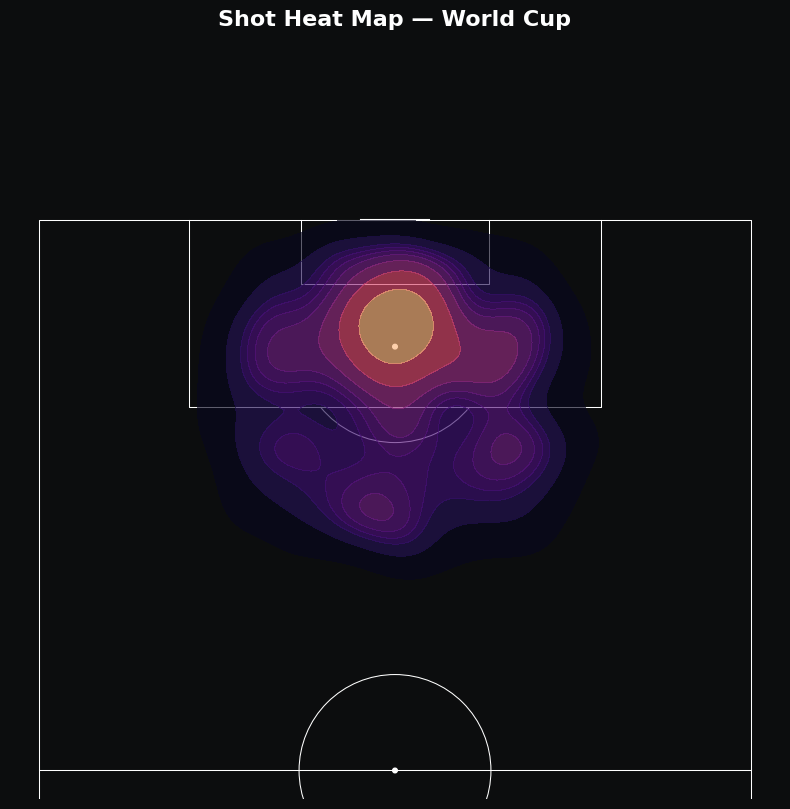

In [58]:
BACKGROUND_COLOR = "#0C0D0E"

pitch = VerticalPitch(
    pitch_type="opta",
    half=True,
    pitch_color=BACKGROUND_COLOR,
    line_color="white",
    linewidth=0.75,
)

fig, ax = pitch.draw(figsize=(8, 10))
fig.patch.set_facecolor(BACKGROUND_COLOR)

pitch.kdeplot(
    df_heat_map["x"],
    df_heat_map["y"],
    ax=ax,
    fill=True,
    levels=10,
    alpha=0.65,
    cmap="magma"
)

fig.text(0.5, 0.97, "Shot Heat Map — World Cup",
         color="white", fontsize=16, fontweight="bold", ha="center")

plt.show()